In [2]:
import getdist.plots as gdplt
import cobaya
from cobaya.yaml import yaml_load_file
from cobaya.run import run
import numpy as np
import os
from scipy import stats
import pandas as pd
from cobaya.yaml import yaml_dump_file
import shutil
import subprocess
import matplotlib.pyplot as plt
from getdist import MCSamples

# DESI2 fullsky

## $\Lambda \text{CDM}$ chains

## cornerplot 

In [3]:
path = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1" # path to the chains
n = [1, 2, 3, 4] # number of chains
files = [path + '.' + str(i) + '.txt' for i in n]

sampler = [[] for _ in range(len(files))]
samples = [[] for _ in range(len(files))]

names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6
# names = [r"hr_\mathrm{drag}", r"\Omega_ch^2", r"\Omega_m"] # --> 2, 3 et 6

for i in range(len(files)):
    print("File", i, ":", files[i])
    sampler[i] = np.loadtxt(files[i])
    dat = [sampler[i][:, 2], sampler[i][:, 6]]
    # dat = [sampler[i][:, 2], sampler[i][:, 3], sampler[i][:, 6]]
    dat = np.array(dat)
    samples[i] = dat.T

File 0 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.1.txt
File 1 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.2.txt
File 2 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.3.txt
File 3 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.4.txt


### plot

Samples shape 0 : (420, 2)
Samples shape 1 : (428, 2)
Samples shape 2 : (427, 2)
Samples shape 3 : (400, 2)


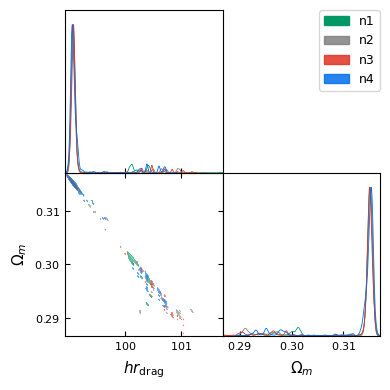

In [4]:
from getdist import MCSamples
# print(samples.shape)
gd_sample = [[] for _ in range(len(samples))]

for i in range(len(samples)):
    print("Samples shape", i, ":", samples[i].shape)
    gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

### cut burn in and plot

(294, 2)
Samples shape 0 : (420, 2)
Taking last 294 samples
(299, 2)
Samples shape 1 : (428, 2)
Taking last 299 samples
(298, 2)
Samples shape 2 : (427, 2)
Taking last 298 samples
(280, 2)
Samples shape 3 : (400, 2)
Taking last 280 samples
Eff. Sample Size for run 1: 26, with sample size : 420 ratio : 0.06
Eff. Sample Size for run 2: 72, with sample size : 428 ratio : 0.17
Eff. Sample Size for run 3: 90, with sample size : 427 ratio : 0.21
Eff. Sample Size for run 4: 56, with sample size : 400 ratio : 0.14


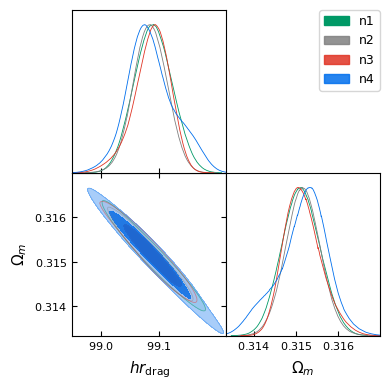

In [5]:
from getdist import MCSamples

for i in range(len(samples)):
    n = samples[i].shape[0] * 0.7
    n = int(n)
    sampl = samples[i][-n:]
    print(sampl.shape)
    print("Samples shape", i, ":", samples[i].shape)
    print("Taking last", n, "samples")
    gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label='n'+str(i+1))
    # gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label=labelH0[i])

    # gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

eff_size_all = [sample.getEffectiveSamples() for sample in gd_sample]
for i in range(len(samples)):
    print(f"Eff. Sample Size for run {i+1}: {round(eff_size_all[i])}, with sample size : {samples[i].shape[0]}",
          f"ratio : {round(eff_size_all[i]/samples[i].shape[0], 2)}")

Expected values are $\Omega_m = 0.3$ and $hr_d = 102 \ h^{-1}\text{Mpc}$

In [6]:
from getdist import loadMCSamples

# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]

# Get effective sample size for a specific parameter
eff_size_param = [sample.getEffectiveSamples(names[1]) for sample in gd_sample]

print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")
print(f"Effective Sample Size for {names[1]}: {', '.join(str(round(eff_size_param[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 26, 72, 90, 56
Effective Sample Size for \Omega_m: 24, 71, 92, 52


## test MPI implementation

### individual chains

In [ ]:
path = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point01\run1"
ranks = [1, 2, 3, 4]
files = [path + '.' + str(i) + ".txt" for i in ranks]

samples = [[] for _ in range(len(ranks))]

names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6
# names = [r"hr_\mathrm{drag}", r"\Omega_ch^2", r"\Omega_m"] # --> 2, 3 et 6

for i in range(len(files)):
    print("File", i, ":", files[i])
    truc = np.loadtxt(files[i])
    dat = [truc[:, 2], truc[:, 6]]
    # dat = [truc[:, 2], truc[:, 3], truc[:, 6]]
    dat = np.array(dat)
    samples[i] = dat.T

File 0 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.1.txt
File 1 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.2.txt
File 2 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.3.txt
File 3 : C:\EPFL\MA4\code\PDM2026\forecast_chains\LCDM\DESI2_fullsky\Rminus1_stop_point05\run1.4.txt


Samples shape 0 : (420, 2)
Samples shape 1 : (428, 2)
Samples shape 2 : (427, 2)
Samples shape 3 : (400, 2)


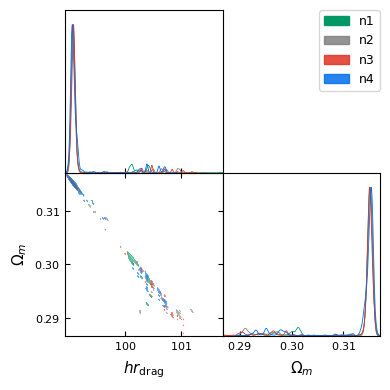

In [ ]:
gd_sample = [[] for _ in range(len(samples))]

for i in range(len(samples)):
    print("Samples shape", i, ":", samples[i].shape)
    gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

(294, 2)
Samples shape 0 : (420, 2)
Taking last 294 samples
(299, 2)
Samples shape 1 : (428, 2)
Taking last 299 samples
(298, 2)
Samples shape 2 : (427, 2)
Taking last 298 samples
(280, 2)
Samples shape 3 : (400, 2)
Taking last 280 samples


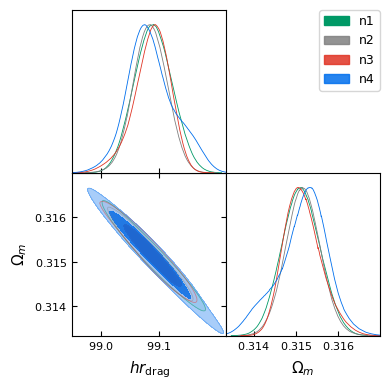

In [ ]:
from getdist import MCSamples
# print(samples.shape)
# for i in range(len(samples)):

#     gdplot = gdplt.get_subplot_plotter()
#     gdplot.triangle_plot(gd_sample, names, filled=True)

# labelH0 = ["H0=40", "H0=50", "H0=60", "H0=70", "H0=80", "H0=90"]

samples_clean = []
for i in range(len(samples)):
    n = samples[i].shape[0] * 0.7
    n = int(n)
    sampl = samples[i][-n:]
    samples_clean.append(sampl)
    print(sampl.shape)
    print("Samples shape", i, ":", samples[i].shape)
    print("Taking last", n, "samples")
    gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label='n'+str(i+1))
    # gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label=labelH0[i])

    # gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))
all_samples_clean = np.concatenate(samples_clean, axis=0)

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

In [ ]:
# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]   
print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 26, 72, 90, 56


## $w_0w_a\mathrm{CDM}$

In [ ]:
from cobaya import load_samples
folder = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point05"
filename = folder + r"\run1"

# gd_sample = [load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z{z}/z{z}", to_getdist=True, skip=0) for z in redshifts]
gd_sample = load_samples(filename, to_getdist=True, skip=0.33)

names = ["hrdrag", "w", "wa", "omegam"] 

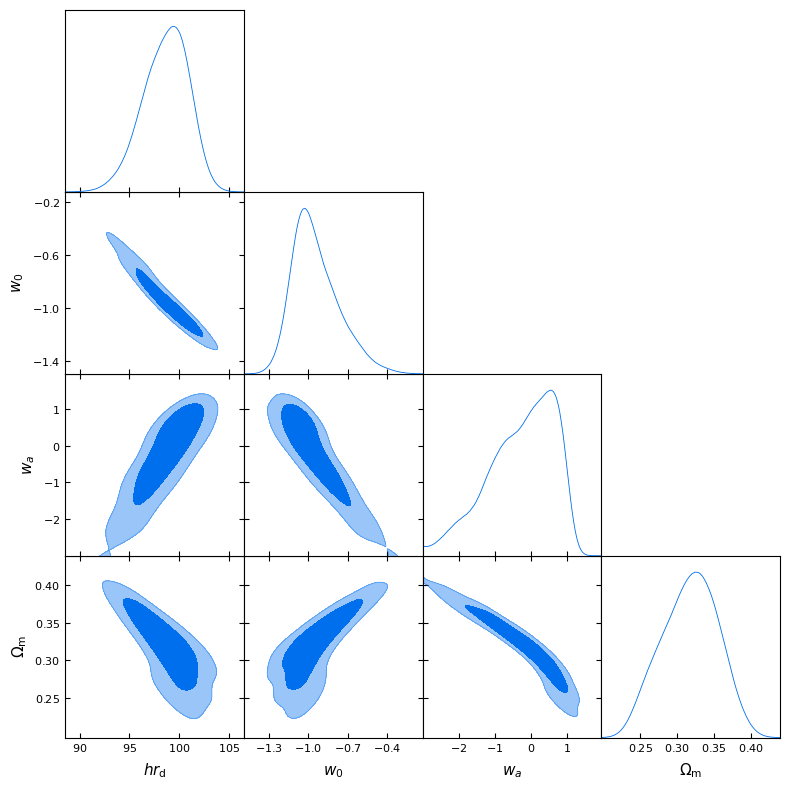

In [ ]:
# Analyze and plot
# for samp in gd_sample:
#     mean = samp.getMeans()[:2]
#     covmat = samp.getCovMat().matrix[:2, :2]
#     print("Mean:")
#     print(mean)
#     print("Covariance matrix:")
#     print(covmat)

import getdist.plots as gdplt

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

((np.float64(-1.495458714871306), np.float64(-0.12530888512869395)),
 (-3.0, np.float64(1.959764856339371)))

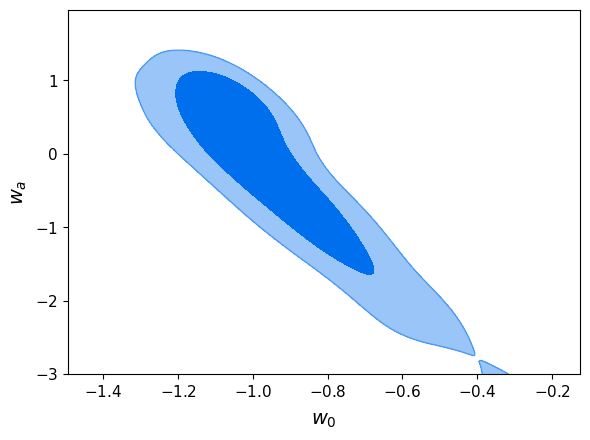

In [ ]:
gdplot = gdplt.get_single_plotter()
gdplot.settings.alpha_filled_add = 0.5  # more transparent fill
# gdplot.settings.alpha_factor_contour_lines = 1  
# gdplot.settings.linewidth_contour = 2.0
# gdplot.settings.num_plot_contours = 1
gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4)
# gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])


In [ ]:
gdplot.settings.alpha_filled_add = 0.25  # more transparent fill
gdplot.settings.linewidth = 2.0          # thicker outlines
gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4)

((-3.0, 1.0), (-3.0, 2.0))

#### $w_0 - w_a$ contours

In [ ]:
path_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point05\run1"
path_DESI_centered_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\DESI_centered\chain"
path_DESI_DR2 = r"C:\EPFL\MA4\code\old_stuff.bak\DESI_DR2_chains\base_w_wa\desi-bao-all\chain"
path_DESI_centered = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2\Rminus1_stop_point01\DESI_centered\chain"
path_DESI_correlated_centered = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2\Rminus1_stop_point01\DESI_correlated_centered\chain"
path_DESI_correlated_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\DESI_correlated_centered\chain"
path_DESI_nP1_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\DESI_nP=1\chain"

In [36]:
from cobaya import load_samples

gd_sample = [load_samples(path_DESI_DR2, to_getdist=True, skip=0.33), load_samples(path_DESI_centered, to_getdist=True, skip=0.33), 
             load_samples(path_DESI_centered_fullsky, to_getdist=True, skip=0.33), load_samples(path_DESI_correlated_centered, to_getdist=True, skip=0.33),
             load_samples(path_DESI_correlated_fullsky, to_getdist=True, skip=0.33)]

names = ["hrdrag", "w", "wa", "omm"] 

# gdplot = gdplt.get_single_plotter()
# gdplot.settings.alpha_filled_add = 1
# gdplot.settings.alpha_factor_contour_lines = 1  
# gdplot.settings.linewidth_contour = 2.0
# gdplot.settings.num_plot_contours = 2
# gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4, lims=[-3, 1, -3, 2])
# gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$"])
# gdplot.add_param_markers({names[1]: -1, names[2]: 0}, lw=1) 
# gdplot.export(f"figures/DESI_data/w_wa_individual/contours_w_wa_z{k}.png")

In [37]:
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

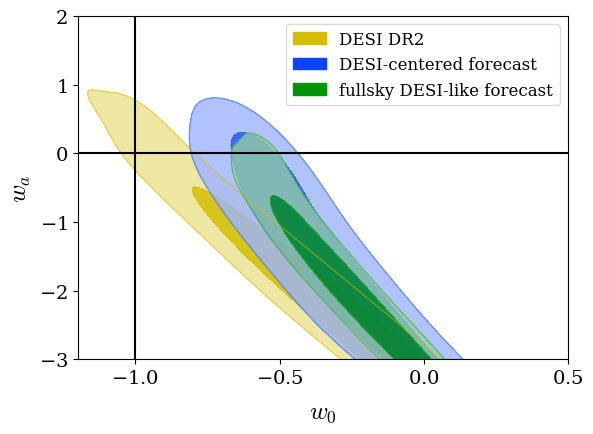

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ['#d3be00', '#0b44ff', '#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

# gdplot.plot_2d(gd_sample, 'w', 'wa',
#     filled=[True, True, True, False],
#     line_args=[
#         {'color': contour_colors[0]},
#         {'color': contour_colors[1]},
#         {'color': contour_colors[2]},
#         {'color': contour_colors[3], 'ls': '--'},
#     ]
# )
gdplot.plot_2d([gd_sample[i] for i in [0, 1, 2]], 'w', 'wa',
    filled=[True, True, True, True],
    line_args=[
        {'color': contour_colors[0]},
        {'color': contour_colors[1]},
        {'color': contour_colors[2]},
        {'color': contour_colors[3]}
    ],
    alphas=[0.9, 0.8, 0.75, 0.5, 0.5]
)

ax = gdplot.get_axes()

# x_fit = np.linspace(-2, 1, 100)

# c_mirage = "#FF0015"
# c_perp   = "#FF4800"
# c_para   = "#FF8800"
# c_nec    = 'b'
# c_steep  = 'k'

# ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
# ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
# ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
# ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
# ax.plot(x_fit, -6    * (x_fit + 1.0),  color=c_steep,  ls=':')

# ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

# legend_handles = [
#     mpatches.Patch(color=contour_colors[1], label='DESI+CMB+Pantheon+'),
#     mpatches.Patch(color=contour_colors[0], label='DESI+CMB+Union3'),
#     mpatches.Patch(color=contour_colors[2], label='DESI+CMB+DESY5'),
#     mlines.Line2D([], [], color=contour_colors[3], ls='--',
#                   label=r'DESI+CMB'),
#     mlines.Line2D([], [], color=c_mirage, ls='-',
#                   label=r'Mirage $\simeq -3.66(w_0+1)$'),
#     mlines.Line2D([], [], color=c_perp,   ls='--',
#                   label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
#     mlines.Line2D([], [], color=c_para,   ls='-.',
#                   label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
#     mlines.Line2D([], [], color=c_nec,    ls=':',
#                   label=r'NEC: $w_a = -(w_0+1)$'),
#     mlines.Line2D([], [], color=c_steep,  ls=':',
#                   label=r'$w_a = -6(w_0+1)$')#,
# ]

legend_handles = [
    mpatches.Patch(color=contour_colors[0], label='DESI DR2'),
    mpatches.Patch(color=contour_colors[1], label='DESI-centered forecast'),
    mpatches.Patch(color=contour_colors[2], label='fullsky DESI-like forecast')#,
    # mpatches.Patch(color=contour_colors[3], label='DESI-correlated forecast')
    ]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7)

ax.set_xlim(-1.2, 0.5)
ax.set_ylim(-3, 2)

fig = gdplot.fig
path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
# fig.savefig(path_to_fig + r'\forecast\w_wa_fullsky_DESI_centered.png', dpi=300)

#### $\Omega_m - hr_d$ contours

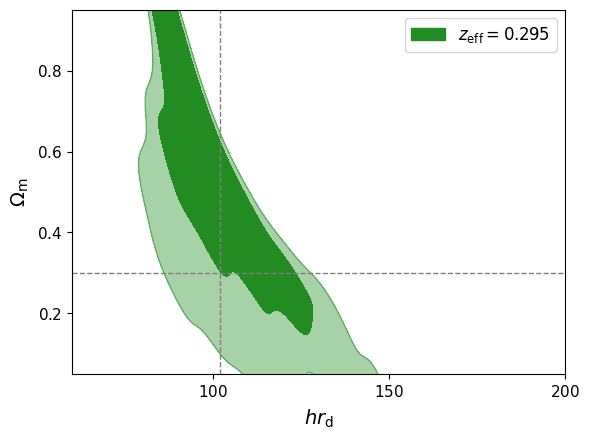

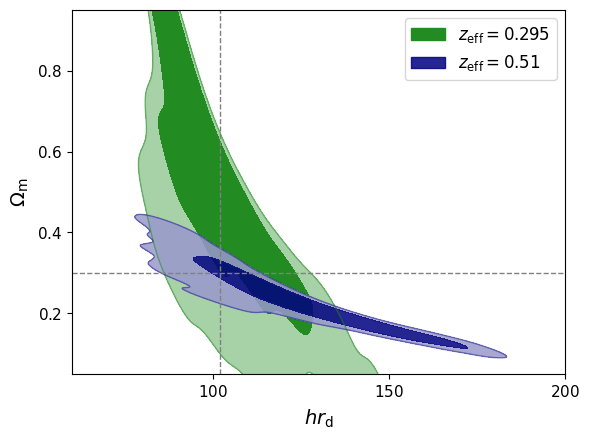

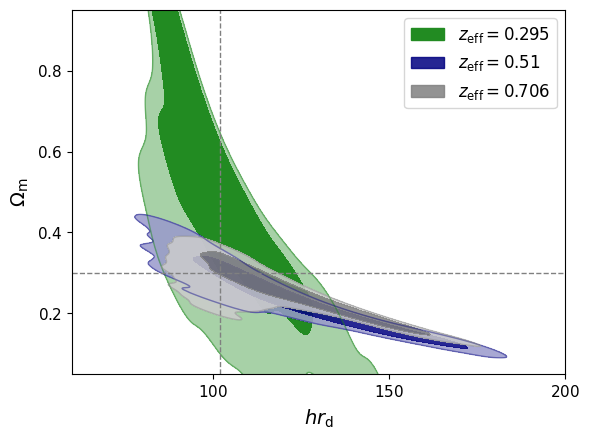

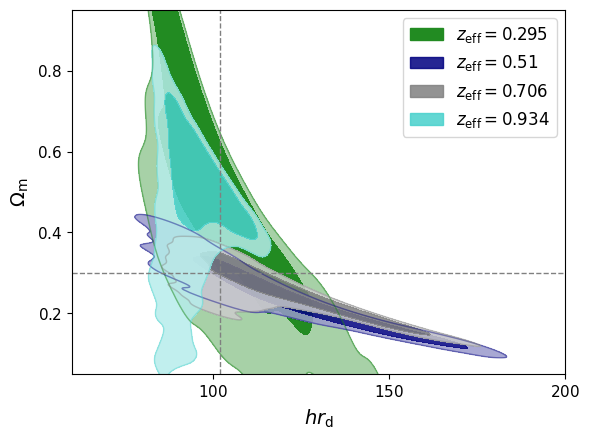

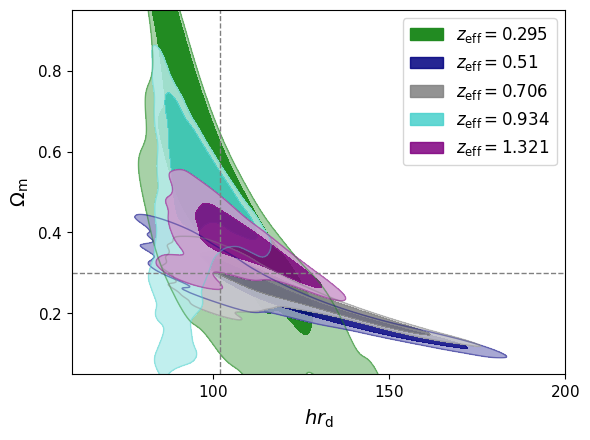

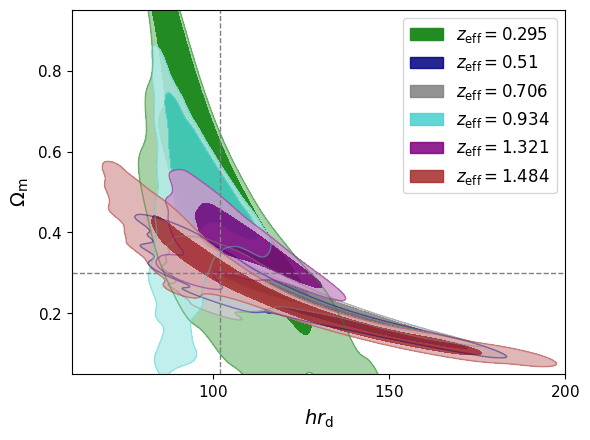

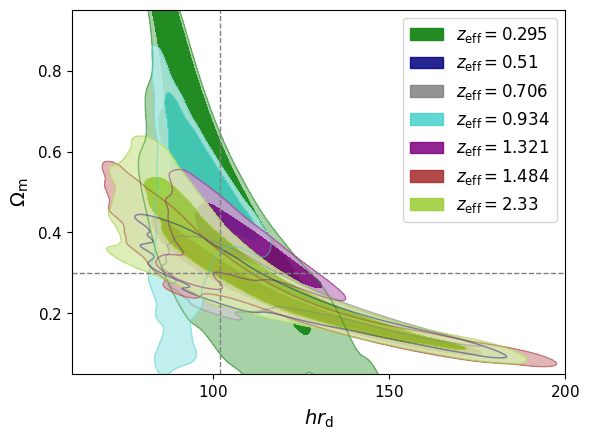

In [19]:
from cobaya import load_samples
redshifts = [1, 2, 3, 4, 5, 6, 7]
# redshifts = [7]
z_values = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
zvalues = [z_values[i-1] for i in redshifts]
colors = ['forestgreen', 'navy', 'gray', 'mediumturquoise', 'purple', 'brown', 'yellowgreen']

gd_sample = [load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z{z}/z{z}", to_getdist=True, skip=0.33) for z in redshifts]
gd_sample[0] = load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z1/z1_2", to_getdist=True, skip=0.33)

names = ["hrdrag", "w", "wa", "omm"] 

for i in range(len(redshifts)):
    # if i ==6:
    # if i ==0:
    gdplot = gdplt.get_single_plotter()
    gdplot.plot_2d(gd_sample[0:i+1], [names[0], names[3]], filled=True, width_inch=4, colors=colors[0:i+1], lims=[60, 200, 0.05, 0.95])
    gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])
    gdplot.settings.alpha_filled_add = 1
    # gdplot.settings.alpha_factor_contour_lines = 1  
    # gdplot.settings.linewidth_contour = 2.0
    gdplot.settings.num_plot_contours = 2
    gdplot.add_param_markers({names[0]: 102.15, names[3]: 0.3}, lw=1) 
    gdplot.export(f"figures/DESI_data/w_wa_individual/contours_Om_hrd_z{i+1}.png")